In [ ]:

# ND5 mRNA structural differences in vivo and in vitro  

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt 

In [ ]:
## 1. Fig 6f --- --- 
### 1_1. check the coverage ND5 --- --- 
### 1_2. check the normalized reactivity ND5 for maximum continous segments --- --- 

In [ ]:
### 1_1. check the coverage ND5 --- --- 

In [5]:
### to get the continuous segment 

def collapse_pos(cov_filter_pos):
    
    values = sorted(cov_filter_pos) 
    first = last = values[0]

    for index in values[1:]:
        if index - last > 1:  # triggered if in a new group
            yield first, last

            first = index  # update first only if in a new group

        last = index  # update last on every iteration

    yield first, last  # this is needed to yield the last set of numbersdef collapse_pos(cov_filter_pos):
    
    values = sorted(cov_filter_pos) 
    first = last = values[0]

    for index in values[1:]:
        if index - last > 1:  # triggered if in a new group
            yield first, last

            first = index  # update first only if in a new group

        last = index  # update last on every iteration

    yield first, last  # this is needed to yield the last set of numbers


def max_segment_transcript(cov_filter_pos):
    
    segment_pos = collapse_pos(cov_filter_pos)
    
    length_segment = [abs(b - a + 1) for a, b in segment_pos]
    max_segment = max(length_segment)

    return max_segment 

(16568, 9)
(16568, 9)
1812
(1812, 17)
0.9900662251655629
0.9812362030905077
0.7831125827814569
0.6892935982339956


/tmp/ipykernel_125007/2265929731.py:84: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df['start'] = df['start'].str.replace('(','')
/tmp/ipykernel_125007/2265929731.py:85: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df['end'] = df['end'].str.replace(')','')
/tmp/ipykernel_125007/2265929731.py:103: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df['start'] = df['start'].str.replace('(','')
/tmp/ipykernel_125007/2265929731.py:104: FutureWarning: The default value of regex will change from True to False in a future version

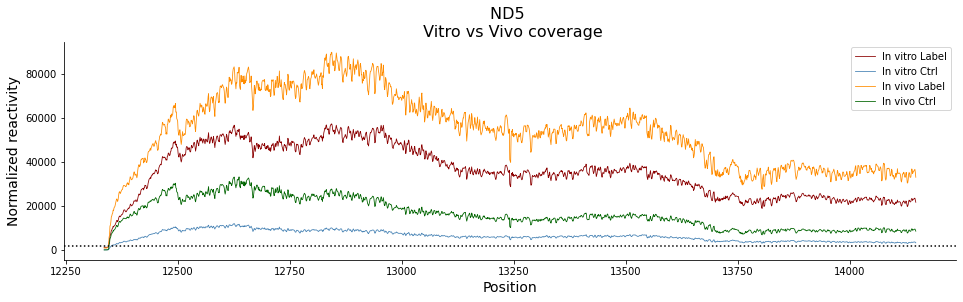

In [6]:
#### input data --- --- 

dir = "./Data/"
vitro = pd.read_csv(dir+'vitro_heavy_NC_012920.1_profile.txt',sep='\t')
vitro = vitro[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
vitro_flt = vitro[vitro['Sequence'] !='N']
vitro_flt = vitro_flt.reset_index(drop=True)
vitro_flt['Position'] = vitro_flt.index+1 
df_vitro = vitro_flt

vivo = pd.read_csv(dir+'vivo_heavy_NC_012920.1_profile.txt',sep='\t')
vivo = vivo[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
vivo_flt = vivo[vivo['Sequence'] !='N']
vivo_flt = vivo_flt.reset_index(drop=True)
vivo_flt['Position'] = vivo_flt.index+1 
df_vivo = vivo_flt

print(df_vitro.shape)
print(df_vivo.shape)

#### mRNA ND5	+	12336	14147
coord = pd.read_csv('./Data/mitochondria_coordinates.csv',sep=',')
start = coord.loc[coord['Gene']=='ND5', 'Start'].values[0]
end = coord.loc[coord['Gene']=='ND5', 'End'].values[0]
len_ND5 = end - start + 1 
print(len_ND5)
combine = pd.merge(df_vitro, df_vivo,how ='inner', on =['Position', 'Position'])
flt = combine[(combine['Position'] >=start) & ((combine['Position'] <=end))]
print(flt.shape)

#### plot the coverage --- ---

dplot = flt
fig, ax = plt.subplots(figsize=(16, 4), sharex=True, sharey=True)
ax.plot(dplot.Position, dplot.Modified_effective_depth_x, linewidth=0.8, color='darkred',label='In vitro Label')  # label="WT (n=%s, %.1d%)" % (flt.shape[0], corr)
ax.plot(dplot.Position, dplot.Untreated_effective_depth_x, linewidth=0.8, color='steelblue',label='In vitro Ctrl')
ax.plot(dplot.Position, dplot.Modified_effective_depth_y, linewidth=0.8, color='darkorange',label='In vivo Label')  # label="WT (n=%s, %.1d%)" % (flt.shape[0], corr)
ax.plot(dplot.Position, dplot.Untreated_effective_depth_y, linewidth=0.8, color='darkgreen',label='In vivo Ctrl')

ax.spines[['right', 'top']].set_visible(False) 
plt.legend(loc='upper right', prop={'size': 10})
ax.set_title('ND5 \n Vitro vs Vivo coverage',fontsize =16)
ax.set_xlabel("Position",size=14)
ax.set_ylabel("Normalized reactivity",size=14)
ax.axhline(y=2000, color='black', linestyle='dotted', lw=1.5)


#### calculate the positions percentage passed coverage cutoff --- ---

flt1 = dplot[(dplot['Modified_effective_depth_x']>=2000) & (dplot['Untreated_effective_depth_x']>=2000) & 
             (dplot['Modified_effective_depth_y']>=2000) & (dplot['Untreated_effective_depth_y']>=2000)]
pct1 = flt1.shape[0]/dplot.shape[0]
print(pct1)

flt2 = dplot[(dplot['Modified_effective_depth_x']>=3000) & (dplot['Untreated_effective_depth_x']>=3000) & 
             (dplot['Modified_effective_depth_y']>=3000) & (dplot['Untreated_effective_depth_y']>=3000)]
pct2 = flt2.shape[0]/dplot.shape[0]
print(pct2)


flt3 = dplot[(dplot['Modified_effective_depth_x']>=4000) & (dplot['Untreated_effective_depth_x']>=4000) & 
             (dplot['Modified_effective_depth_y']>=4000) & (dplot['Untreated_effective_depth_y']>=4000)]
pct3 = flt3.shape[0]/dplot.shape[0]
print(pct3)


flt4 = dplot[(dplot['Modified_effective_depth_x']>=5000) & (dplot['Untreated_effective_depth_x']>=5000) & 
             (dplot['Modified_effective_depth_y']>=5000) & (dplot['Untreated_effective_depth_y']>=5000)]
pct4 = flt4.shape[0]/dplot.shape[0]
print(pct4)


####  get continous segment at coverage 2000
segment_pos = collapse_pos(flt1.Position)
length_segment = [abs(b - a + 1) for a,b in segment_pos]
loc_list = list(collapse_pos(flt1.Position))

df = pd.DataFrame({'loca' :  loc_list,
                   'length' : length_segment,
                  } 
                  )
df['loca'] = df['loca'].astype(str)
df[['start','end']] = df['loca'].str.split(",",expand=True)
df['start'] = df['start'].str.replace('(','')
df['end'] = df['end'].str.replace(')','')
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int) 
df=df.drop_duplicates()
df1=df
df1['coverage'] = 2000

####  get continous segment at coverage 3000
segment_pos = collapse_pos(flt2.Position)
length_segment = [abs(b - a + 1) for a,b in segment_pos]
loc_list = list(collapse_pos(flt2.Position))

df = pd.DataFrame({'loca' :  loc_list,
                   'length' : length_segment,
                  } 
                  )
df['loca'] = df['loca'].astype(str)
df[['start','end']] = df['loca'].str.split(",",expand=True)
df['start'] = df['start'].str.replace('(','')
df['end'] = df['end'].str.replace(')','')
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int) 
df=df.drop_duplicates()
df2=df
df2['coverage'] = 3000


####  get continous segment at coverage 4000
segment_pos = collapse_pos(flt3.Position)
length_segment = [abs(b - a + 1) for a,b in segment_pos]
loc_list = list(collapse_pos(flt3.Position))

df = pd.DataFrame({'loca' :  loc_list,
                   'length' : length_segment,
                  } 
                  )
df['loca'] = df['loca'].astype(str)
df[['start','end']] = df['loca'].str.split(",",expand=True)
df['start'] = df['start'].str.replace('(','')
df['end'] = df['end'].str.replace(')','')
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int) 
df=df.drop_duplicates()
df3=df
df3['coverage'] = 4000


####  get continous segment at coverage 5000
segment_pos = collapse_pos(flt4.Position)
length_segment = [abs(b - a + 1) for a,b in segment_pos]
loc_list = list(collapse_pos(flt4.Position))

df = pd.DataFrame({'loca' :  loc_list,
                   'length' : length_segment,
                  } 
                  )
df['loca'] = df['loca'].astype(str)
df[['start','end']] = df['loca'].str.split(",",expand=True)
df['start'] = df['start'].str.replace('(','')
df['end'] = df['end'].str.replace(')','')
df['start'] = df['start'].astype(int)
df['end'] = df['end'].astype(int) 
df=df.drop_duplicates()
df4=df
df4['coverage'] = 5000

dfall = pd.concat([df1,df2,df3,df4]) 
dir_out = "./Data/"
dfall.to_csv(dir_out+'continous_segments_at_different_coverage_cutoff.txt',sep='\t') 

In [ ]:
### 1_2. check the normalized reactivity ND5 for maximum continous segments --- --- 
#### ND5 max segment:   12368	14127  at coverage 3000 --- --- 

In [7]:
### input data 
#### in vitro winsorize 2.5% and re-normlization--------------------------------------------------------------------------------

dir = "./Data/"
vitro = pd.read_csv(dir+'vitro_heavy_NC_012920.1_profile.txt',sep='\t')
vitro = vitro[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
vitro_flt = vitro[vitro['Sequence'] !='N']  
vitro_flt = vitro_flt.reset_index(drop=True)
vitro_flt['Position'] = vitro_flt.index+1 
vitro_flt.columns
vitro2 = vitro_flt
vitro_flt = vitro_flt[(vitro_flt['Modified_effective_depth'] >=3000) & (vitro_flt['Untreated_effective_depth'] >=3000)]

reactivity_flt_1 = vitro_flt[vitro_flt['Reactivity_profile'].notnull()] 
per_99 = reactivity_flt_1.Reactivity_profile.quantile(0.975)
per_1 = reactivity_flt_1.Reactivity_profile.quantile(0.025)
print(per_99)
print(per_1)
vitro_flt['Reactivity_profile'] = np.where(vitro_flt['Reactivity_profile'] >= per_1, vitro_flt['Reactivity_profile'], per_1)
vitro_flt['Reactivity_profile'] = np.where(vitro_flt['Reactivity_profile'] <= per_99, vitro_flt['Reactivity_profile'], per_99)

reactivity_flt = vitro_flt[vitro_flt['Reactivity_profile'].notnull()] 

per_25 = reactivity_flt.Reactivity_profile.quantile(0.25)
per_75 = reactivity_flt.Reactivity_profile.quantile(0.75)
per_90 = reactivity_flt.Reactivity_profile.quantile(0.90)
interquartile = per_75 - per_25
max_cutoff =  max(interquartile*1.5, per_90)

flt_above_max = reactivity_flt[(reactivity_flt['Reactivity_profile'] >= max_cutoff)] 
flt_below_max = reactivity_flt[(reactivity_flt['Reactivity_profile'] < max_cutoff)] 
        
flt_per_90 = flt_below_max.Reactivity_profile.quantile(0.9)
flt_per_100 = flt_below_max.Reactivity_profile.quantile(1.00)
flt_remain_10 = flt_below_max[(flt_below_max['Reactivity_profile'] < flt_per_100) & (flt_below_max['Reactivity_profile'] > flt_per_90)] 
mean_remain_10 = flt_remain_10.Reactivity_profile.mean()
print(mean_remain_10)   

norm_value = (vitro_flt.Reactivity_profile/mean_remain_10).tolist()
print(len(norm_value))
vitro_flt['Norm_profile_winsor'] = norm_value
dfnorm = vitro_flt[['Position','Norm_profile_winsor']]
vitro_new = pd.merge(vitro2,dfnorm,how='left',on=['Position','Position'])
print(vitro_new.Norm_profile_winsor.max())
print(vitro_new.Norm_profile_winsor.min())


#### in vivo winsorize 2.5% and re-normlization--------------------------------------------------------------------------------

dir = "./Data/"
vivo = pd.read_csv(dir+'vivo_heavy_NC_012920.1_profile.txt',sep='\t')
vivo = vivo[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
vitro_flt = vivo[vivo['Sequence'] !='N']
vivo_flt = vivo_flt.reset_index(drop=True)
vivo_flt['Position'] = vivo_flt.index+1 
vivo_flt.columns
vivo2 = vivo_flt
vivo_flt = vivo_flt[(vivo_flt['Modified_effective_depth'] >=3000) & (vivo_flt['Untreated_effective_depth'] >=3000)]

reactivity_flt_1 = vivo_flt[vivo_flt['Reactivity_profile'].notnull()] 
per_99 = reactivity_flt_1.Reactivity_profile.quantile(0.975)
per_1 = reactivity_flt_1.Reactivity_profile.quantile(0.025)
print(per_99)
print(per_1)
vivo_flt['Reactivity_profile'] = np.where(vivo_flt['Reactivity_profile'] >= per_1, vivo_flt['Reactivity_profile'], per_1)
vivo_flt['Reactivity_profile'] = np.where(vivo_flt['Reactivity_profile'] <= per_99, vivo_flt['Reactivity_profile'], per_99)

reactivity_flt = vivo_flt[vivo_flt['Reactivity_profile'].notnull()] 

per_25 = reactivity_flt.Reactivity_profile.quantile(0.25)
per_75 = reactivity_flt.Reactivity_profile.quantile(0.75)
per_90 = reactivity_flt.Reactivity_profile.quantile(0.90)
interquartile = per_75 - per_25
max_cutoff =  max(interquartile*1.5, per_90) 

flt_above_max = reactivity_flt[(reactivity_flt['Reactivity_profile'] >= max_cutoff)] 
flt_below_max = reactivity_flt[(reactivity_flt['Reactivity_profile'] < max_cutoff)] 
        
flt_per_90 = flt_below_max.Reactivity_profile.quantile(0.90)
flt_per_100 = flt_below_max.Reactivity_profile.quantile(1.00)
flt_remain_10 = flt_below_max[(flt_below_max['Reactivity_profile'] < flt_per_100) & (flt_below_max['Reactivity_profile'] > flt_per_90)] 
mean_remain_10 = flt_remain_10.Reactivity_profile.mean()
print(mean_remain_10)   

norm_value = (vivo_flt.Reactivity_profile/mean_remain_10).tolist()
print(len(norm_value))
vivo_flt['Norm_profile_winsor'] = norm_value
dfnorm = vivo_flt[['Position','Norm_profile_winsor']]
vivo_new = pd.merge(vivo2,dfnorm,how='left',on=['Position','Position'])
print(vivo_new.Norm_profile_winsor.max())
print(vivo_new.Norm_profile_winsor.min())

combine = pd.merge(vitro_new, vivo_new,how ='inner', on =['Position', 'Position'])
combine = combine[(combine['Modified_effective_depth_x'] >=3000) & (combine['Untreated_effective_depth_x'] >=3000) & (combine['Modified_effective_depth_y'] >=3000) & (combine['Untreated_effective_depth_y'] >=3000)]

0.005225099999999996
-0.0011319
0.0020354745484400657
13565
2.5670180961016564
-0.5560865405403661
0.0010532999999999992
-0.00037729999999999996
0.0004930318181818182
12349
2.1363732748209117
-0.7652650114781453


/tmp/ipykernel_125007/3045664344.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vitro_flt['Reactivity_profile'] = np.where(vitro_flt['Reactivity_profile'] >= per_1, vitro_flt['Reactivity_profile'], per_1)
/tmp/ipykernel_125007/3045664344.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vitro_flt['Reactivity_profile'] = np.where(vitro_flt['Reactivity_profile'] <= per_99, vitro_flt['Reactivity_profile'], per_99)
/tmp/ipykernel_125007/3045664344.py:41: SettingWithCopyWarning: 
A value is trying to be

0.3816230912430593


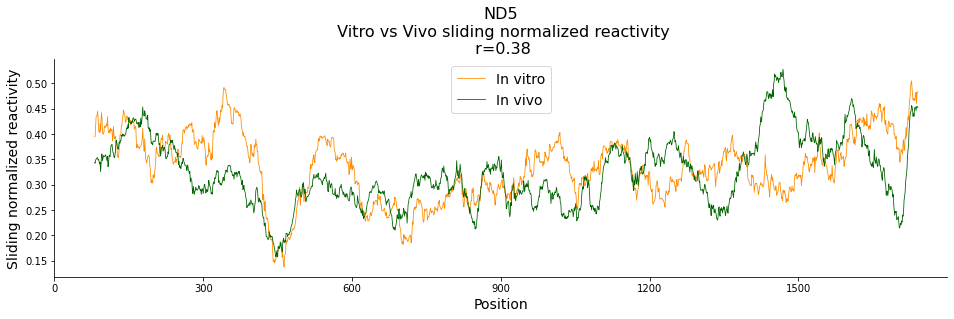

In [9]:
#### plot normalized reactivity window 100nt
#### rolling raectivity for window 

flt = combine[(combine['Position'] >=12368) & ((combine['Position'] <=14127))]
out = "./Data/"
flt.to_csv(out+'source_data_fig6f.csv',sep=',')

roll_vitro = flt['Norm_profile_winsor_x'].rolling(100).mean()
roll_vivo = flt['Norm_profile_winsor_y'].rolling(100).mean()

tmp1 = pd.DataFrame(roll_vitro)
tmp1.columns = ['slide']
tmp1['group'] = 'vitro'
tmp1['Position'] = tmp1.index+1-50

tmp2 = pd.DataFrame(roll_vivo)
tmp2.columns = ['slide']
tmp2['group'] = 'vivo'
tmp2['Position'] = tmp2.index+1-50

win = pd.merge(tmp1,tmp2,how='inner',on=['Position','Position'])
win=win.dropna()
stat = stats.pearsonr(win.slide_x, win.slide_y)
print(stat[0])

#### plotting ... ...

fig, ax = plt.subplots(figsize=(16, 4), sharex=True, sharey=True)
ax.plot(win.Position-12336, win.slide_x, linewidth=0.8, color='darkorange',label='In vitro')  # label="WT (n=%s, %.1d%)" % (flt.shape[0], corr)
ax.plot(win.Position-12336, win.slide_y, linewidth=0.8, color='darkgreen',label='In vivo')
ax.spines[['right', 'top']].set_visible(False) 
plt.legend(loc='upper center', prop={'size': 14})
ax.set_title('ND5' + '\n Vitro vs Vivo sliding normalized reactivity'+ '\n r='+str(round(stat[0],2)),fontsize =16)
ax.set_xlabel("Position",size=14)
ax.set_ylabel("Sliding normalized reactivity",size=14)
ax.set_xlim([0,1800])
ax.xaxis.set_ticks(np.arange(0,1800, 300))

dir_out = "./Data/"
plt.savefig(dir_out+'Fig6f_ND5_normalzied_reactivity_vivo_vs_vitro.pdf',bbox_inches='tight', dpi=300) 
